# Ejercicio 8 - Datos de 2025 y analisis completo

## 8.1 y 8.2 Descarga
Se agrego 2025 a `ANIOS` en `scripts/download_data.py`. Corrida: 24 archivos descargados (12 yellow + 12 green de 2025), 40 ya existian y se omitieron;
segunda corrida: 0 descargados, 64 existentes. `verify_data.py --anios 2024 2025 2026`: todos los tipos/anios completos
(ver `docs/02_descarga.md`).

In [1]:
import sys; sys.path.insert(0, "../scripts")
import labutil as lu
import matplotlib.pyplot as plt
con = lu.connect()
COL = {2024: "#9ecae1", 2025: "#4292c6", 2026: "#08306b"}

## 8.3 Las consultas anteriores siguen funcionando
Se reejecutan sin cambios las consultas del EDA (`04_*`) y de la incorporacion (`05_*`) sobre los tres anios.

In [2]:
import glob, os
for f in sorted(glob.glob(str(lu.SQL_DIR / "0[345]_*.sql"))):
    n = os.path.basename(f)
    try:
        df = lu.q(con, n, mostrar_sql=False)
        print(f"OK   {n:34} {len(df):6} filas")
    except Exception as e:
        print(f"FALLO {n}: {e}")

OK   03_01_files.sql                         2 filas
OK   03_02_rows_per_file.sql                64 filas
OK   03_03_total_rows.sql                    3 filas
OK   03_04_schema_yellow.sql                21 filas
OK   03_05_schema_green.sql                 22 filas


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

OK   03_06_sample.sql                        5 filas


OK   03_07_quality.sql                       2 filas


OK   03_08_dates_out_of_range.sql           15 filas


...

OK   04_08_outliers.sql                      7 filas


OK   04_09_top_zones.sql                    20 filas
OK   05_01_files_by_year.sql                 6 filas


OK   05_02_rows_by_year.sql                  6 filas


OK   05_03_schema_drift.sql                  6 filas


OK   05_04_monthly_both_years.sql           64 filas


Todas las consultas se ejecutan. Las que contenian conteos absolutos (p. ej. `03_03_total_rows`) simplemente devuelven valores mayores:
las consultas no cambian, cambian sus resultados.

## 8.4 Indicadores actualizados
El tablero de tres anios esta en `docs/dashboard.png` y se muestra en el notebook 07.

## 8.5 y 8.7 Evolucion de los indicadores
Comparacion justa en los meses comunes (enero-agosto), ya que 2026 solo llega hasta agosto.

In [3]:
yoy = lu.q(con, "08_01_yoy_jan_aug.sql"); yoy.set_index("anio").T

-- 08_01_yoy_jan_aug.sql
-- Comparacion justa entre anios: solo enero-agosto (los meses que existen en los tres anios).
-- Fuente: trips_clean.
SELECT data_year AS anio, count(*) AS viajes, round(sum(total_amount) / 1e6, 1) AS ingresos_musd,
       round(avg(fare_amount), 2) AS tarifa_media,
       round(100.0 * avg(CASE WHEN taxi = 'green' THEN 1 ELSE 0 END), 2) AS pct_verde,
       round(100.0 * avg(CASE WHEN payment_type = 1 THEN 1 ELSE 0 END), 1) AS pct_tarjeta,
       round(100.0 * avg(CASE WHEN payment_type = 0 THEN 1 ELSE 0 END), 1) AS pct_flex,
       round(100.0 * avg(CASE WHEN payment_type = 2 THEN 1 ELSE 0 END), 1) AS pct_efectivo,
       round(sum(trip_distance) / (sum(date_diff('second', pickup, dropoff)) / 3600.0), 2) AS velocidad_mph,
       round(100.0 * avg(CASE WHEN coalesce(cbd_congestion_fee, 0) > 0 THEN 1 ELSE 0 END), 1) AS pct_cbd
FROM trips_clean WHERE data_month <= 8 GROUP BY data_year ORDER BY data_year;



anio,2024,2025,2026
viajes,25911647.00,29059072.00,28539846.00
ingresos_musd,732.10,822.10,861.70
tarifa_media,19.50,19.55,21.25
pct_verde,1.61,1.29,1.11
pct_tarjeta,75.80,68.70,65.40
pct_flex,8.80,19.40,24.70
pct_efectivo,14.00,10.20,9.20
velocidad_mph,12.51,12.57,11.93
pct_cbd,0.00,72.20,71.70


In [4]:
import pandas as pd
d = yoy.set_index("anio")
var = pd.DataFrame({"2025 vs 2024 (%)": (d.loc[2025] / d.loc[2024] - 1) * 100, "2026 vs 2025 (%)": (d.loc[2026] / d.loc[2025] - 1) * 100})
var.loc[["viajes", "ingresos_musd", "tarifa_media", "velocidad_mph"]].round(1)

,2025 vs 2024 (%),2026 vs 2025 (%)
viajes,12.1,-1.8
ingresos_musd,12.3,4.8
tarifa_media,0.3,8.7
velocidad_mph,0.5,-5.1


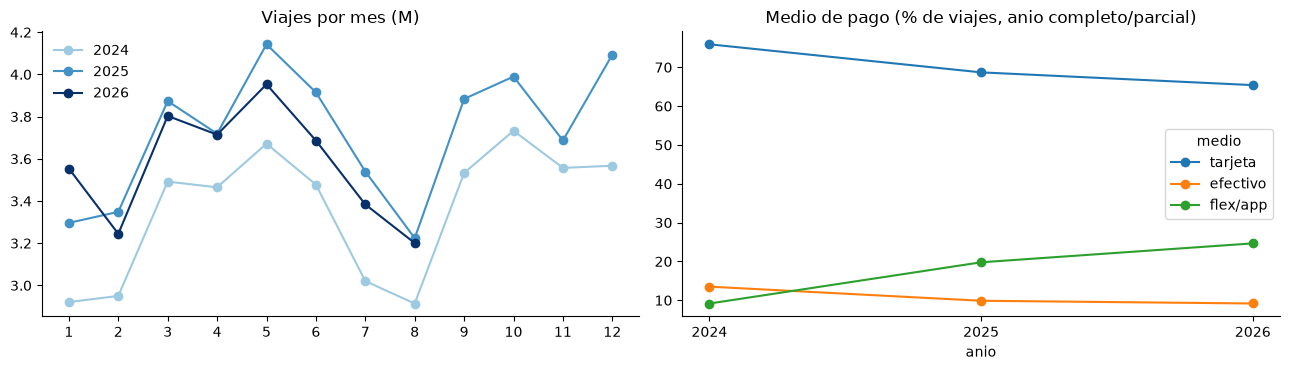

In [5]:
m = lu.q(con, "07_i1_monthly_trips.sql", mostrar_sql=False)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
for a, g in m.groupby("anio"):
    ax[0].plot(g.mes, g.viajes / 1e6, marker="o", color=COL[a], label=a)
ax[0].set(title="Viajes por mes (M)", xticks=range(1, 13)); ax[0].legend(frameon=False)
p = lu.q(con, "07_i6_payment_mix.sql", mostrar_sql=False).pivot(index="anio", columns="medio", values="pct")
p[["tarjeta", "efectivo", "flex/app"]].plot(ax=ax[1], marker="o"); ax[1].set(title="Medio de pago (% de viajes, anio completo/parcial)", xticks=[2024, 2025, 2026])
for a in ax: a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 8.6 Cambios y patrones visibles al considerar 2024-2026

1. **La demanda crecio en 2025 y se enfria en 2026.** Ene-ago: 25.9 M (2024) -> 29.1 M (2025, +12%) -> 28.5 M (2026, -1.8%). Sin embargo los **ingresos** siguen subiendo
   (732 -> 822 -> 862 M USD) porque la **tarifa media sube** a 21.25 USD en 2026 (+8.7% sobre 2025, tras un 2025 casi plano). Es decir, el crecimiento de 2026 es de precio, no de volumen.
2. **Cambio estructural en el pago/captura:** `payment_type = 0` (flex/app) pasa de 8.8% a 19.4% y 24.7%, desplazando a tarjeta (75.8 -> 68.7 -> 65.4%) y, en menor medida, a efectivo (14.0 -> 10.2 -> 9.2%).
   Quien analice propinas o pasajeros debe tenerlo en cuenta, porque esos viajes carecen de `passenger_count` y casi de propina.
3. **Nuevo cargo regulatorio:** `cbd_congestion_fee` aparece desde enero 2025 y lo paga ~72% de los viajes (0.75 USD) tanto en 2025 como en 2026; en 2024 no existe (NULL).
4. **El taxi verde pierde terreno:** su participacion cae de 1.61% a 1.29% y 1.11% (ene-ago) y su tarifa media baja mientras la del amarillo sube.
5. **Velocidad:** estable en 2024-2025 (~12.5 mph) y ~5% mas lenta en 2026 (11.9 mph), consistente con mas trafico/viajes mas largos en tiempo aunque haya menos viajes; la causa no se puede determinar solo con estos datos.